In [13]:
import pypsa
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

In [26]:
n = pypsa.Network("/data/PyPSA-GH/results/networks/elec_s_6_ec_lcopt_4H.nc")
# CORRECT
print("Network loaded - Least-cost optimisation network (lcopt, 2030 costs)")

INFO:pypsa.io:Imported network elec_s_6_ec_lcopt_4H.nc has buses, carriers, generators, lines, links, loads, storage_units, stores


Network loaded - Least-cost optimisation network (lcopt, 2030 costs)


Evaluating the scale of the model

In [5]:
print(f"Snapshots: {len(n.snapshots)}")
print(f"Buses: {len(n.buses)}")
print(f"Lines: {len(n.lines)}")
print(f"Generators: {len(n.generators)}")
print(f"Storage: {len(n.storage_units)}")
print(f"n\nDate range: {n.snapshots[0]} ---> {n.snapshots[-1]}")


Snapshots: 2184
Buses: 21
Lines: 6
Generators: 45
Storage: 2
n
Date range: 2013-01-01 00:00:00 ---> 2013-12-30 20:00:00


In [6]:
print("==== BUSES === ")
print(n.buses[["x", "y", "carrier", "country"]])

==== BUSES === 
                      x          y  carrier country
Bus                                                
GH0 0         -0.321650   5.583410       AC      GH
GH0 1         -2.115422   7.835856       AC      GH
GH0 2         -1.702414   5.208771       AC      GH
GH0 3         -1.490211  10.311944       AC      GH
GH0 4         -1.507208   6.443125       AC      GH
GH0 5         -0.026917   6.174417       AC      GH
GH1 0          0.400500   7.099950       AC      GH
GH0 0 H2      -0.321650   5.583410       H2      GH
GH0 1 H2      -2.115422   7.835856       H2      GH
GH0 2 H2      -1.702414   5.208771       H2      GH
GH0 3 H2      -1.490211  10.311944       H2      GH
GH0 4 H2      -1.507208   6.443125       H2      GH
GH0 5 H2      -0.026917   6.174417       H2      GH
GH1 0 H2       0.400500   7.099950       H2      GH
GH0 0 battery -0.321650   5.583410  battery      GH
GH0 1 battery -2.115422   7.835856  battery      GH
GH0 2 battery -1.702414   5.208771  battery     

In [7]:
# Generators, what power plants exis
#p_nom = installed capacity (MW)
#carrier = fuel type

print("=== GENERATORS===")
print(n.generators[["bus", "carrier", "p_nom"]].sort_values("carrier"))

=== GENERATORS===
                                       bus        carrier        p_nom
Generator                                                             
GH0 0 CCGT                           GH0 0           CCGT  1817.154566
GH0 2 CCGT                           GH0 2           CCGT  1765.000000
GH0 1 load shedding                  GH0 1  load shedding   494.723303
GH0 2 load shedding                  GH0 2  load shedding   379.691709
GH0 3 load shedding                  GH0 3  load shedding   588.588334
GH0 4 load shedding                  GH0 4  load shedding   915.966821
GH0 5 load shedding                  GH0 5  load shedding   288.536125
GH1 0 load shedding                  GH1 0  load shedding   289.162972
GH0 0 H2 load shedding            GH0 0 H2  load shedding     0.000000
GH0 1 H2 load shedding            GH0 1 H2  load shedding     0.000000
GH0 2 H2 load shedding            GH0 2 H2  load shedding     0.000000
GH0 3 H2 load shedding            GH0 3 H2  load shedding  

In [8]:
print("=== LINES (GRIDCO TRANSMISSION )===")
print(n.lines[["bus0", "bus1", "s_nom", "length"]].to_string())

=== LINES (GRIDCO TRANSMISSION )===
       bus0   bus1        s_nom      length
Line                                       
0     GH0 0  GH0 2  1465.730675  198.035282
1     GH0 0  GH0 5  1259.053713   91.698372
2     GH0 1  GH0 3   359.729632  354.695885
3     GH0 1  GH0 4  1465.730675  210.972482
4     GH0 2  GH0 4  1465.730675  173.677566
5     GH0 4  GH0 5   359.729632  207.887422


In [ ]:
# Cell 6 — Define bus labels (we derived these from coordinates)
bus_names = {
    "GH0 0": "Accra",
    "GH0 1": "Kumasi",
    "GH0 2": "Takoradi",
    "GH0 3": "Tamale",
    "GH0 4": "Obuasi/ Mining belt",
    "GH0 5": "Tema",
    "GH1 0": "Akosombo"
}

In [10]:
# Cell 7 — Installed capacity by carrier (MW)
# Filter only real generators (drop load shedding, zero-capacity wind)

real_carriers = ["CCGT", "oil", "hydro", "solar", "onwind"]

gen = n.generators.copy()
gen_real = gen[gen["carrier"].isin(real_carriers)].copy()

# Also pull hydro from storage_units (PyPSA stores hydro there sometimes)
stor = n.storage_units.copy()
print("Storage unit carriers:", stor["carrier"].unique())
print(stor[["bus", "carrier", "p_nom"]])

Storage unit carriers: ['hydro']
               bus carrier   p_nom
StorageUnit                       
GH0 1 hydro  GH0 1   hydro   404.0
GH0 5 hydro  GH0 5   hydro  1180.0


In [11]:
# Cell 8 — Aggregate installed capacity by carrier

cap_gen = gen_real.groupby("carrier")["p_nom"].sum()

# Add storage hydro if present
hydro_stor = stor[stor["carrier"].str.contains("hydro|ror|reservoir", case=False, na=False)]
if not hydro_stor.empty:
    hydro_mw = hydro_stor["p_nom"].sum()
    cap_gen["hydro (storage)"] = hydro_mw

print("=== INSTALLED CAPACITY BY CARRIER (MW) ===")
print(cap_gen.sort_values(ascending=False).round(1))
print(f"\nTOTAL: {cap_gen.sum():.0f} MW")

=== INSTALLED CAPACITY BY CARRIER (MW) ===
carrier
CCGT               3582.2
hydro (storage)    1584.0
oil                 879.5
solar               548.8
onwind                0.0
Name: p_nom, dtype: float64

TOTAL: 6594 MW


In [14]:
# Cell 9 — Validation Reference: IRENA 2024 + Energy Commission Ghana 2025
# Sources:
#   IRENA Renewable Capacity Statistics 2026 H1 (C-ELECCAP file, Ghana, 2024)
#   Energy Commission Ghana, "2025 Energy Outlook for Ghana", Table 1 (Dec 2024)

# ── CAPACITY (MW) ─────────────────────────────────────────────────────
ref_capacity = pd.DataFrame({
    "IRENA_2024_MW": {
        "Hydro":       1584.05,
        "Natural Gas": 3743.50,
        "Oil":          370.00,
        "Solar PV":     173.36,
        "Wind":           0.02,
        "Bioenergy":      0.10,
    },
    "EC_2024_MW": {
        "Hydro":       1584.00,   # Akosombo 1020 + Bui 404 + Kpong 160
        "Natural Gas": 3676.00,   # all gas thermal plants (excl. embedded)
        "Oil":          370.00,   # AKSA plant
        "Solar PV":     132.00,   # grid-connected solar only
        "Wind":           0.00,
        "Bioenergy":      0.10,   # Safisana biogas
    }
})
ref_capacity["Diff_%"] = (
    (ref_capacity["IRENA_2024_MW"] - ref_capacity["EC_2024_MW"])
    / ref_capacity["EC_2024_MW"] * 100
).round(1)

print("=== CAPACITY VALIDATION (MW) ===")
print(ref_capacity.round(1))

# ── GENERATION MIX (GWh) — EC 2025 projections (primary) ──────────────
ref_generation = pd.DataFrame({
    "EC_2025_proj_GWh": {
        "Hydro":    8561,    # Akosombo 6205 + Kpong 1095 + Bui 1261
        "Thermal": 16997,    # all gas+oil thermal
        "Solar/RE":  196,    # solar PV + biogas
        "Import":     82,
    },
    "IRENA_2023_GWh": {      # latest available from IRENA
        "Hydro":    8193,
        "Thermal": 14930,
        "Solar/RE":  239,
        "Import":      0,
    }
})
ref_generation["EC_share_%"] = (
    ref_generation["EC_2025_proj_GWh"] 
    / ref_generation["EC_2025_proj_GWh"].sum() * 100
).round(1)

print("\n=== GENERATION MIX REFERENCE ===")
print(ref_generation)
print(f"\nEC 2025 target: Hydro 33.1% | Thermal 65.8% | RE 0.8%")

=== CAPACITY VALIDATION (MW) ===
             IRENA_2024_MW  EC_2024_MW  Diff_%
Hydro               1584.0      1584.0     0.0
Natural Gas         3743.5      3676.0     1.8
Oil                  370.0       370.0     0.0
Solar PV             173.4       132.0    31.3
Wind                   0.0         0.0     inf
Bioenergy              0.1         0.1     0.0

=== GENERATION MIX REFERENCE ===
          EC_2025_proj_GWh  IRENA_2023_GWh  EC_share_%
Hydro                 8561            8193        33.1
Thermal              16997           14930        65.8
Solar/RE               196             239         0.8
Import                  82               0         0.3

EC 2025 target: Hydro 33.1% | Thermal 65.8% | RE 0.8%


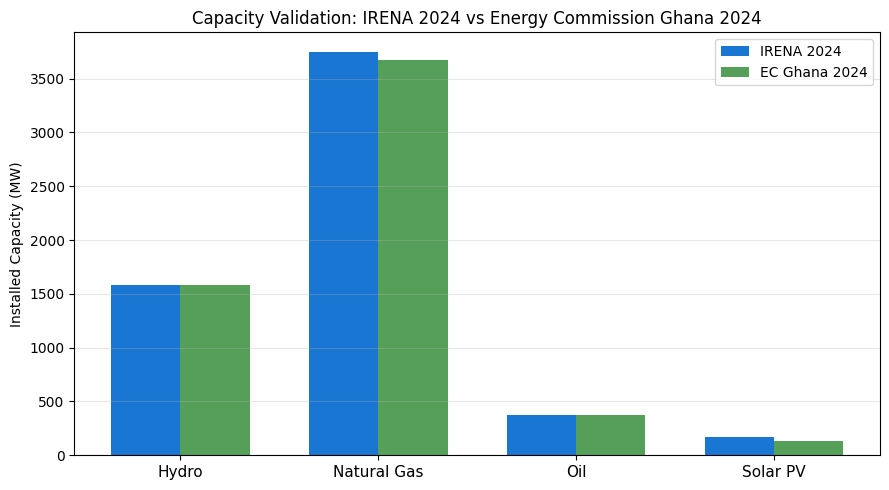

In [15]:
# Cell 10 — Plot: Capacity comparison IRENA vs EC
import matplotlib.pyplot as plt
import numpy as np

techs = ["Hydro", "Natural Gas", "Oil", "Solar PV"]
irena_vals = [ref_capacity.loc[t, "IRENA_2024_MW"] for t in techs]
ec_vals    = [ref_capacity.loc[t, "EC_2024_MW"] for t in techs]

x = np.arange(len(techs))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, irena_vals, w, label="IRENA 2024", color="#1976D2")
ax.bar(x + w/2, ec_vals,    w, label="EC Ghana 2024", color="#388E3C", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(techs, fontsize=11)
ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Capacity Validation: IRENA 2024 vs Energy Commission Ghana 2024")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig1_capacity_validation.png", dpi=150)
plt.show()

In [16]:
# ============================================================
# STEP 3A — Extract model capacity by carrier
# This is what PyPSA-GH actually has installed
# ============================================================

# Pull generators (exclude load shedding — those are slack variables, not real plants)
gen = n.generators.copy()
gen_real = gen[~gen["carrier"].str.contains("load shedding", case=False, na=False)].copy()

# Pull storage units — hydro reservoirs live here in PyPSA-Earth
stor = n.storage_units.copy()
print("Storage carriers:", stor["carrier"].unique())
print(stor[["bus", "carrier", "p_nom"]].to_string())

Storage carriers: ['hydro']
               bus carrier   p_nom
StorageUnit                       
GH0 1 hydro  GH0 1   hydro   404.0
GH0 5 hydro  GH0 5   hydro  1180.0


In [17]:
# ============================================================
# STEP 3B — Aggregate model capacity by carrier
# ============================================================

# Generators (CCGT, oil, solar, onwind etc.)
model_cap_gen = gen_real.groupby("carrier")["p_nom"].sum()

# Storage (hydro, PHS etc.)
model_cap_stor = stor.groupby("carrier")["p_nom"].sum()

# Combine
model_capacity = pd.concat([model_cap_gen, model_cap_stor]).groupby(level=0).sum()
model_capacity = model_capacity[model_capacity > 0.1].sort_values(ascending=False)

print("=== MODEL INSTALLED CAPACITY (MW) ===")
print(model_capacity.round(1))
print(f"\nModel Total: {model_capacity.sum():.0f} MW")
print(f"EC Reference Total (excl embedded): 5,260 MW")

=== MODEL INSTALLED CAPACITY (MW) ===
carrier
CCGT     3582.2
hydro    1584.0
oil       879.5
solar     548.8
Name: p_nom, dtype: float64

Model Total: 6594 MW
EC Reference Total (excl embedded): 5,260 MW


In [18]:
# ============================================================
# STEP 3C — Side-by-side comparison table
# Map model carriers → validation categories
# ============================================================

# Adjust these keys based on what Step 3B prints
carrier_map = {
    "CCGT":          "Gas Thermal",
    "gas":           "Gas Thermal",
    "oil":           "Oil Thermal",
    "hydro":         "Hydro",
    "ror":           "Hydro",
    "solar":         "Solar PV",
    "onwind":        "Wind",
    "offwind-ac":    "Wind",
    "offwind-dc":    "Wind",
    "biomass":       "Bioenergy",
}

model_cap_mapped = model_capacity.copy()
model_cap_mapped.index = [carrier_map.get(c, c) for c in model_cap_mapped.index]
model_cap_mapped = model_cap_mapped.groupby(level=0).sum()

# Reference values (IRENA 2024 + EC 2024 — confirmed numbers)
reference = pd.Series({
    "Gas Thermal": 3743.5,   # IRENA 2024 Natural Gas OnGrid
    "Oil Thermal":  370.0,   # IRENA 2024 Oil OnGrid (AKSA)
    "Hydro":       1584.0,   # IRENA 2024 = EC exact match
    "Solar PV":     173.4,   # IRENA 2024 OnGrid
    "Wind":           0.0,
    "Bioenergy":      0.1,
}, name="IRENA/EC Reference (MW)")

comparison = pd.DataFrame({
    "Model (MW)":     model_cap_mapped.round(1),
    "Reference (MW)": reference,
}).fillna(0)

comparison["Diff (MW)"] = (comparison["Model (MW)"] - comparison["Reference (MW)"]).round(1)
comparison["Diff (%)"]  = (comparison["Diff (MW)"] / comparison["Reference (MW)"].replace(0, 1) * 100).round(1)

print("=== VALIDATION 1: CAPACITY ===")
print(comparison.to_string())

=== VALIDATION 1: CAPACITY ===
             Model (MW)  Reference (MW)  Diff (MW)  Diff (%)
Bioenergy           0.0             0.1       -0.1    -100.0
Gas Thermal      3582.2          3743.5     -161.3      -4.3
Hydro            1584.0          1584.0        0.0       0.0
Oil Thermal       879.5           370.0      509.5     137.7
Solar PV          548.8           173.4      375.4     216.5
Wind                0.0             0.0        0.0       0.0


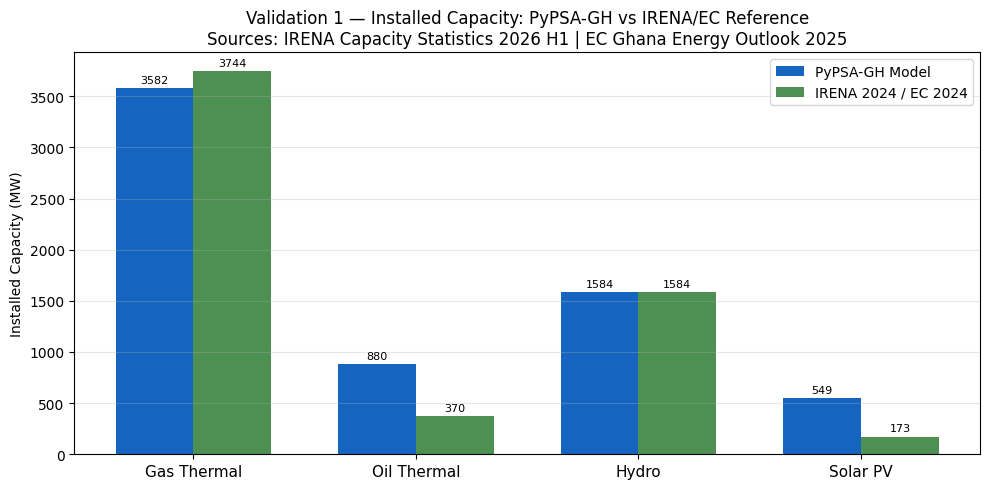

In [19]:
# ============================================================
# STEP 3D — Capacity validation bar chart
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

cats = ["Gas Thermal", "Oil Thermal", "Hydro", "Solar PV"]
model_vals = [comparison.loc[c, "Model (MW)"] if c in comparison.index else 0 for c in cats]
ref_vals   = [comparison.loc[c, "Reference (MW)"] if c in comparison.index else 0 for c in cats]

x = np.arange(len(cats))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, model_vals, w, label="PyPSA-GH Model", color="#1565C0")
bars2 = ax.bar(x + w/2, ref_vals,   w, label="IRENA 2024 / EC 2024", color="#2E7D32", alpha=0.85)

# Add value labels on bars
for bar in bars1 + bars2:
    h = bar.get_height()
    if h > 10:
        ax.text(bar.get_x() + bar.get_width()/2, h + 30, f"{h:.0f}", 
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Validation 1 — Installed Capacity: PyPSA-GH vs IRENA/EC Reference\n"
             "Sources: IRENA Capacity Statistics 2026 H1 | EC Ghana Energy Outlook 2025")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig1_capacity_validation.png", dpi=150)
plt.show()

In [28]:
# ============================================================
# STEP 3E — Generation mix (dispatch) validation
# CORRECT
# How does the least-cost 2030 optimised dispatch compare to Ghana's observed 2024 mix?
# Get total dispatch from model results
# generators_t.p = actual dispatch time series (MW at each snapshot)
gen_dispatch = n.generators_t.p.copy()

# Remove load shedding columns
real_cols = [c for c in gen_dispatch.columns 
             if "load shedding" not in c.lower()]
gen_dispatch = gen_dispatch[real_cols]

# Map to carriers
col_carrier = n.generators.loc[real_cols, "carrier"]
gen_by_carrier = gen_dispatch.T.groupby(col_carrier).sum().T

# Also get storage dispatch (hydro)
stor_dispatch = n.storage_units_t.p.copy()
stor_carrier  = n.storage_units["carrier"]
stor_by_carrier = stor_dispatch.T.groupby(stor_carrier).sum().T

print("Generator carriers dispatched:", list(gen_by_carrier.columns))
print("Storage carriers dispatched:",   list(stor_by_carrier.columns))

Generator carriers dispatched: ['CCGT', 'offwind-ac', 'offwind-dc', 'oil', 'onwind', 'solar']
Storage carriers dispatched: ['hydro']


In [21]:
# ============================================================
# STEP 3F — Annual generation totals (GWh) + mix %
# ============================================================

# Each snapshot = 4H, so multiply MW by 4 to get MWh, divide by 1000 for GWh
dt = 4  # hours per snapshot

gen_gwh  = (gen_by_carrier.sum() * dt / 1000).round(1)
stor_gwh = (stor_by_carrier.sum() * dt / 1000).round(1)
stor_gwh = stor_gwh[stor_gwh > 0]  # keep only positive dispatch

print("=== MODEL ANNUAL GENERATION (GWh) ===")
print("Generators:")
print(gen_gwh.sort_values(ascending=False))
print("\nStorage (hydro etc.):")
print(stor_gwh)

total_gwh = gen_gwh.sum() + stor_gwh.sum()
print(f"\nModel Total: {total_gwh:.0f} GWh")
print(f"EC 2025 Reference Total: 25,836 GWh")

=== MODEL ANNUAL GENERATION (GWh) ===
Generators:
carrier
solar         8166.8
CCGT          3415.6
offwind-ac       0.0
offwind-dc       0.0
oil              0.0
onwind           0.0
dtype: float64

Storage (hydro etc.):
carrier
hydro    8103.4
dtype: float64

Model Total: 19686 GWh
EC 2025 Reference Total: 25,836 GWh


=== VALIDATION 2: GENERATION MIX ===
          Model (%)  EC 2025 (%)  IRENA 2023 (%)
Hydro          41.2         33.1            35.1
Thermal        17.4         65.8            63.9
Solar/RE       41.5          0.8             1.0


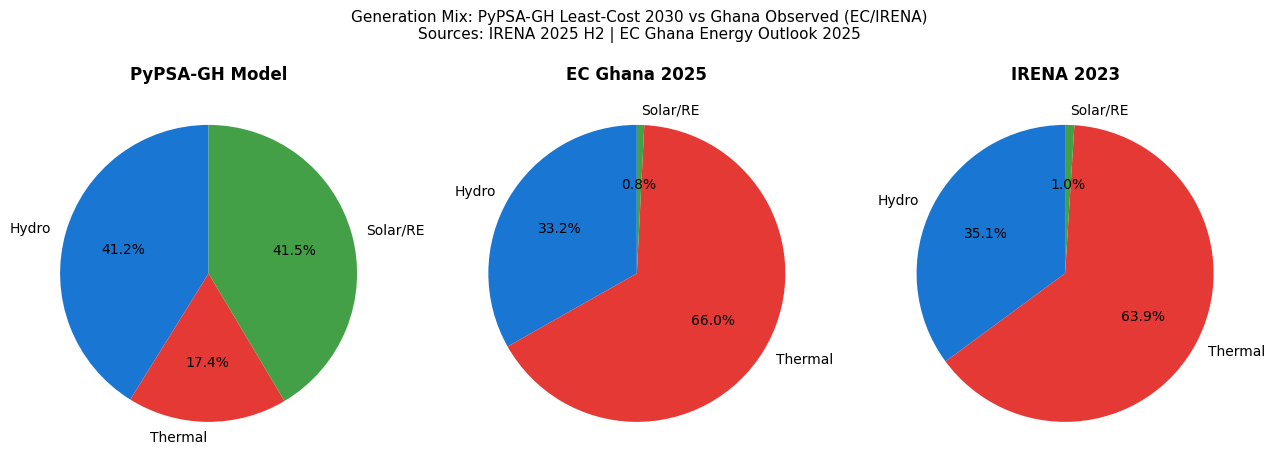

In [29]:
# ============================================================
# STEP 3G — Generation mix pie: Model vs EC 2025 reference
# ============================================================

# Aggregate model into Hydro / Thermal / Solar+RE
hydro_carriers   = ["hydro", "ror", "PHS"]
thermal_carriers = ["CCGT", "gas", "oil", "OCGT"]
solar_carriers   = ["solar", "onwind", "offwind-ac", "offwind-dc", "biomass"]

def sum_carriers(series, carriers):
    return sum(series.get(c, 0) for c in carriers)

all_gwh = pd.concat([gen_gwh, stor_gwh])
model_mix = pd.Series({
    "Hydro":    sum_carriers(all_gwh, hydro_carriers),
    "Thermal":  sum_carriers(all_gwh, thermal_carriers),
    "Solar/RE": sum_carriers(all_gwh, solar_carriers),
})
model_mix_pct = (model_mix / model_mix.sum() * 100).round(1)

ec_mix_pct = pd.Series({
    "Hydro":    33.1,
    "Thermal":  65.8,
    "Solar/RE":  0.8,
}, name="EC 2025 (%)")

irena_mix_pct = pd.Series({
    "Hydro":    35.1,
    "Thermal":  63.9,
    "Solar/RE":  1.0,
}, name="IRENA 2023 (%)")

print("=== VALIDATION 2: GENERATION MIX ===")
print(pd.DataFrame({
    "Model (%)":    model_mix_pct,
    "EC 2025 (%)":  ec_mix_pct,
    "IRENA 2023 (%)": irena_mix_pct,
}))

# Pie charts side by side
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
colors = ["#1976D2", "#E53935", "#43A047"]
labels = ["Hydro", "Thermal", "Solar/RE"]

for ax, vals, title in zip(axes,
    [model_mix_pct, ec_mix_pct, irena_mix_pct],
    ["PyPSA-GH Model", "EC Ghana 2025", "IRENA 2023"]):
    ax.pie(vals, labels=labels, autopct="%1.1f%%", colors=colors,
           startangle=90, textprops={"fontsize": 10})
    ax.set_title(title, fontsize=12, fontweight="bold")

# CORRECT — change suptitle to:
fig.suptitle(
    "Generation Mix: PyPSA-GH Least-Cost 2030 vs Ghana Observed (EC/IRENA)\n"
    "Sources: IRENA 2025 H2 | EC Ghana Energy Outlook 2025",
    fontsize=11
)
plt.tight_layout()
plt.savefig("fig2_generation_mix.png", dpi=150)
plt.show()

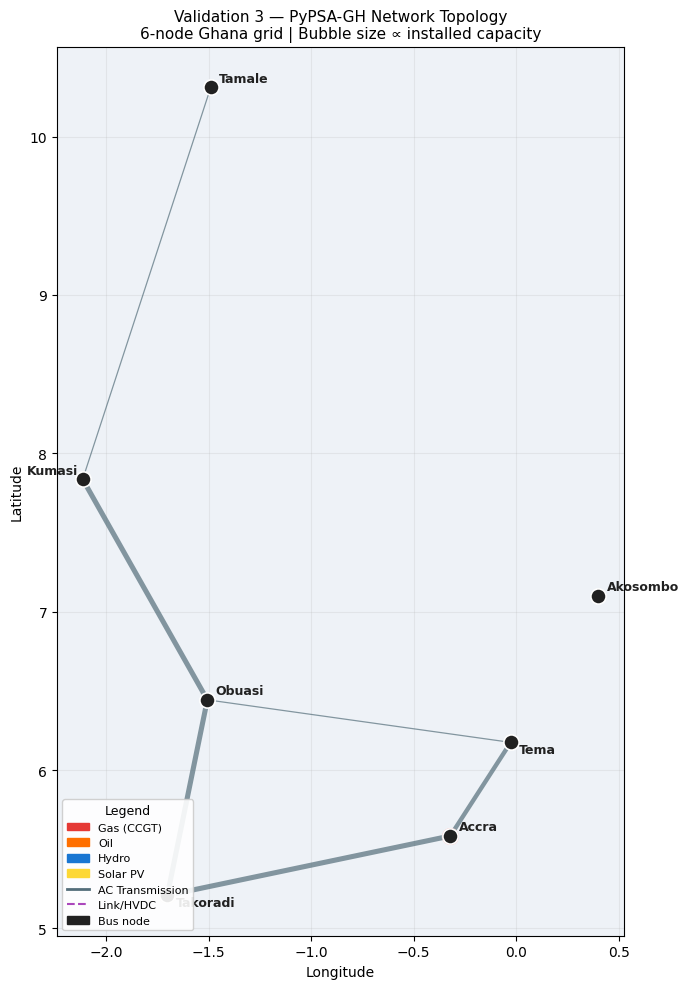

In [ ]:
# ============================================================
# STEP 3H — NETWORK MAP (Validation 3)
# Buses, transmission lines, generators on Ghana geography
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

# Bus name mapping from coordinates (confirmed earlier)
bus_names = {
    "GH0 0": "Accra",
    "GH0 1": "Kumasi",
    "GH0 2": "Takoradi",
    "GH0 3": "Tamale",
    "GH0 4": "Obuasi/Mining belt",
    "GH0 5": "Tema",
    "GH1 0": "Akosombo",
}

# Carrier colors for generator dots
carrier_colors = {
    "CCGT":   "#E53935",   # red = gas
    "gas":    "#E53935",
    "oil":    "#FF6F00",   # orange = oil
    "hydro":  "#1976D2",   # blue = hydro
    "ror":    "#1976D2",
    "solar":  "#FDD835",   # yellow = solar
    "onwind": "#43A047",   # green = wind
}

ac_buses = n.buses[n.buses["carrier"] == "AC"].copy()
ac_buses["label"] = ac_buses.index.map(bus_names)

fig, ax = plt.subplots(figsize=(7, 10))
ax.set_facecolor("#EEF2F7")

# ── Transmission lines ───────────────────────────────────────
for _, line in n.lines.iterrows():
    try:
        b0 = n.buses.loc[line["bus0"]]
        b1 = n.buses.loc[line["bus1"]]
        lw = max(0.8, line["s_nom"] / 400)
        ax.plot([b0["x"], b1["x"]], [b0["y"], b1["y"]],
                color="#546E7A", linewidth=lw, alpha=0.7, zorder=2)
    except KeyError:
        pass

# Also draw links (HVDC or cross-border)
for _, link in n.links.iterrows():
    try:
        b0 = n.buses.loc[link["bus0"]]
        b1 = n.buses.loc[link["bus1"]]
        ax.plot([b0["x"], b1["x"]], [b0["y"], b1["y"]],
                color="#AB47BC", linewidth=1.2, alpha=0.6,
                linestyle="--", zorder=2)
    except KeyError:
        pass

# ── Generator bubbles (sized by p_nom) ───────────────────────
for _, gen_row in n.generators.iterrows():
    if "load shedding" in gen_row["carrier"].lower():
        continue
    if gen_row["p_nom"] < 1:
        continue
    try:
        bus = n.buses.loc[gen_row["bus"]]
        color = carrier_colors.get(gen_row["carrier"], "#90A4AE")
        size  = max(30, gen_row["p_nom"] / 12)
        ax.scatter(bus["x"], bus["y"], s=size, color=color,
                   alpha=0.55, zorder=3, edgecolors="white", linewidths=0.4)
    except KeyError:
        pass

# ── Bus nodes ────────────────────────────────────────────────
ax.scatter(ac_buses["x"], ac_buses["y"], s=120, color="#212121",
           zorder=5, edgecolors="white", linewidths=1.2)

# ── Bus labels ───────────────────────────────────────────────
offsets = {
    "Accra":     ( 6,  4), "Kumasi":   (-40,  4),
    "Takoradi":  ( 6, -8), "Tamale":   (  6,  4),
    "Obuasi":    ( 6,  4), "Tema":     ( 6, -8),
    "Akosombo":  ( 6,  4),
}
for _, row in ac_buses.iterrows():
    label = row["label"]
    dx, dy = offsets.get(label, (6, 4))
    ax.annotate(label, (row["x"], row["y"]),
                textcoords="offset points", xytext=(dx, dy),
                fontsize=9, fontweight="bold", color="#212121")

# ── Legend ───────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color="#E53935", label="Gas (CCGT)"),
    mpatches.Patch(color="#FF6F00", label="Oil"),
    mpatches.Patch(color="#1976D2", label="Hydro"),
    mpatches.Patch(color="#FDD835", label="Solar PV"),
    mlines.Line2D([],[],color="#546E7A", linewidth=2, label="AC Transmission"),
    mlines.Line2D([],[],color="#AB47BC", linewidth=1.5,
                  linestyle="--", label="Link/HVDC"),
    mpatches.Patch(color="#212121", label="Bus node"),
]
ax.legend(handles=legend_items, loc="lower left", fontsize=8,
          framealpha=0.9, title="Legend", title_fontsize=9)

ax.set_title("Validation 3 — PyPSA-GH Network Topology\n"
             "6-node Ghana grid | Bubble size ∝ installed capacity",
             fontsize=11)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("fig3_network_map.png", dpi=150)
plt.show()

In [24]:
# ============================================================
# STEP 3I — Load profile at each bus (demand shape)
# Confirms load is correctly distributed across Ghana's nodes
# ============================================================

load_t = n.loads_t.p_set.copy()
load_static = n.loads[["bus", "carrier"]].copy()

# Map bus → city name
load_static["city"] = load_static["bus"].map(bus_names)

# Annual energy demand per bus (GWh)
load_annual = (load_t.sum() * 4 / 1000)  # 4H resolution → GWh
load_annual.name = "Annual Load (GWh)"

load_summary = load_static.copy()
load_summary["Annual_GWh"] = load_summary.index.map(load_annual)
print("=== LOAD BY BUS (GWh/year) ===")
print(load_summary[["city","bus","Annual_GWh"]].sort_values(
      "Annual_GWh", ascending=False).to_string())
print(f"\nTotal model load: {load_annual.sum():.0f} GWh")
print(f"EC 2025 reference: 25,836 GWh")

=== LOAD BY BUS (GWh/year) ===
           city    bus   Annual_GWh
Load                               
GH0 4    Obuasi  GH0 4  4995.296906
GH0 0     Accra  GH0 0  3477.597356
GH0 3    Tamale  GH0 3  3209.912645
GH0 1    Kumasi  GH0 1  2698.012338
GH0 2  Takoradi  GH0 2  2070.678515
GH1 0  Akosombo  GH1 0  1576.972947
GH0 5      Tema  GH0 5  1573.554390

Total model load: 19602 GWh
EC 2025 reference: 25,836 GWh


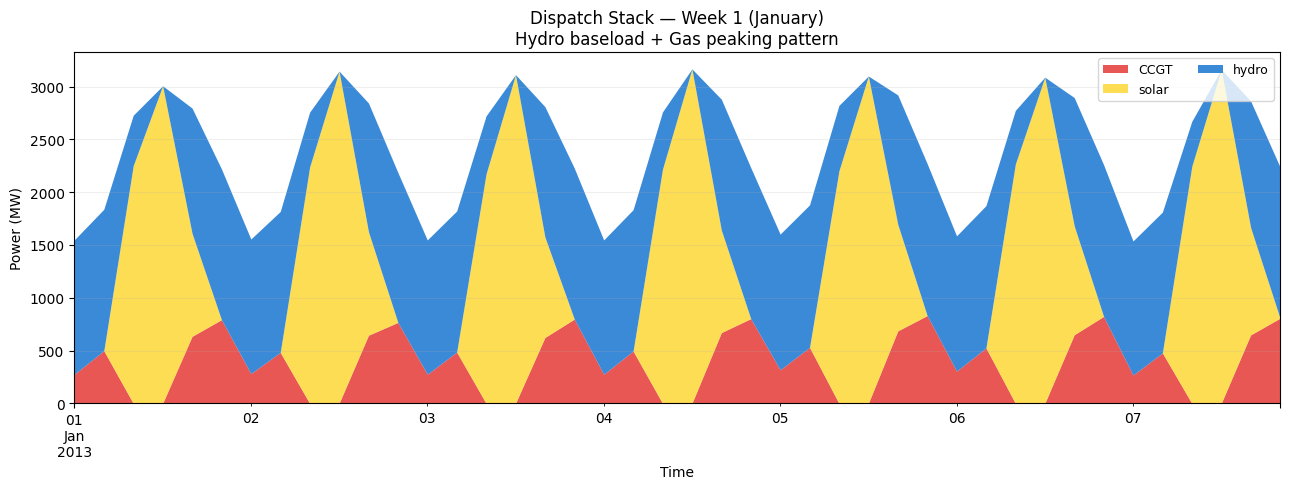

In [ ]:
# ============================================================
# STEP 3J — Weekly dispatch stack (what runs when?)
# Shows hydro vs thermal operating pattern
# ============================================================

# Take one representative week (January, week 1)
week = slice(0, 42)  # 42 snapshots = 7 days × 6 per day at 4H

all_dispatch = pd.concat([gen_by_carrier, stor_by_carrier], axis=1).fillna(0)

# Keep only carriers with meaningful generation
major = all_dispatch.columns[all_dispatch.max() > 10]
dispatch_week = all_dispatch.loc[:, major].iloc[week]

carrier_plot_colors = {
    "CCGT":   "#E53935", "gas":   "#E53935",
    "oil":    "#FF6F00", "hydro": "#1976D2",
    "ror":    "#42A5F5", "solar": "#FDD835",
    "onwind": "#66BB6A", "biomass": "#8D6E63",
}
plot_colors = [carrier_plot_colors.get(c, "#90A4AE") for c in dispatch_week.columns]

fig, ax = plt.subplots(figsize=(13, 5))
dispatch_week.plot.area(ax=ax, color=plot_colors, alpha=0.85, linewidth=0)
ax.set_title("Dispatch Stack — Week 1 (January)\nLeast-cost 2030 optimised: solar + hydro dominant")
ax.set_ylabel("Power (MW)")
ax.set_xlabel("Time")
ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("fig4_dispatch_stack.png", dpi=150)
plt.show()